<a href="https://colab.research.google.com/github/Mariagiusi23/Graph-Coloring/blob/main/graph_coloring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Colorazione di grafi con GNN e minimizzazione differenziabile dell'energia di Potts**

*Eleonora De Cicco 2047514 - Mariagiusi Nicodemo 2114171*

**Introduzione al problema**

Il problema della colorazione consiste nell'assegnare a ogni nodo di un grafo non orientato uno tra `c` colori, imponendo che nodi collegati da un arco abbiano colori diversi. Una colorazione è valida quando il numero di archi in conflitto è zero.In questo progetto il problema discreto viene affrontato come ottimizzazione differenziabile. Una Graph Neural Network viene allenata direttamente su ciascun grafo e produce, per ogni nodo, una distribuzione continua sui colori. L'ottimizzazione minimizza una loss ispirata all'hamiltoniana antiferromagnetica del modello di Potts; al termine, l'assegnazione continua viene discretizzata tramite `argmax`.L'obiettivo sperimentale è applicare il metodo ai grafi assegnati `g6` e `g12`, studiare il numero di conflitti al variare di `c` e stimare il più piccolo numero di colori per cui la pipeline trova una colorazione valida.

**Interpretazione dei risultati.** Il metodo è stocastico e non dimostra il numero cromatico esatto. Ogni colorazione valida trovata fornisce soltanto un **upper bound osservato** sul numero cromatico.

##**1. Setup**


In [ ]:
from pathlib import Path
from dataclasses import dataclass, replace
from typing import Optional, Tuple, List, Union
import os
import sys
import random
import subprocess
import importlib.util
import urllib.request

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn


def ensure_package(import_name: str, pip_name: Optional[str] = None) -> None:
    """Installa un pacchetto solo se non è già disponibile."""
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

# NetworkX serve per la baseline greedy e per la visualizzazione.
ensure_package("networkx")
import networkx as nx

# PyTorch Geometric è usato qui solo per Data, come nel notebook ReadGraph_example del corso.
ensure_package("torch_geometric", "torch-geometric")
from torch_geometric.data import Data

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"

for directory in [RAW_DIR, FIG_DIR, TAB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PyTorch:", torch.__version__)



Device: cpu
PyTorch: 2.11.0+cpu


## 2. **Dataset e lettura dei grafi**
I due grafi assegnati, `g6.col` e `g12.col`, sono forniti in formato DIMACS. La funzione `read_dimacs_col_pyg` legge i nodi e gli archi, converte gli indici da 1-based a 0-based e costruisce un oggetto `torch_geometric.data.Data`.Per il resto dell'analisi viene usata la classe `GraphData`, che conserva:
* `edge_index`, con gli archi nei due versi, usato per il message passing;

* `unique_edges`, con un'unica copia di ogni arco non orientato, usato per loss, conteggio dei conflitti e baseline.

Il controllo iniziale su numero di nodi, archi, densità e gradi permette di verificare la corretta lettura dei file.

In [ ]:
# @title
GRAPH_FILENAMES = {
    "g6": "g6.col",
    "g12": "g12.col",
}

RAW_BASE_URL = "https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi"


def find_or_download_graph(filename: str) -> Path:
    """Trova il file in Colab oppure lo scarica dal repository del corso."""
    candidates = [
        PROJECT_ROOT / filename,
        RAW_DIR / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    target = RAW_DIR / filename
    url = f"{RAW_BASE_URL}/{filename}"
    try:
        print(f"Scarico {filename} da {url}")
        urllib.request.urlretrieve(url, target)
        return target
    except Exception as exc:
        raise FileNotFoundError(
            f"File {filename} non trovato. Caricalo in Colab nella cartella corrente "
            f"oppure in {RAW_DIR}. Errore download: {exc}"
        )


def read_dimacs_col_pyg(
    path: Union[str, Path],
    make_undirected: bool = True,
    remove_self_loops: bool = True,
    dtype: torch.dtype = torch.float32,
) -> Data:
    """
    Legge un grafo di colorazione in formato DIMACS .col e lo converte
    in un oggetto PyTorch Geometric Data.

    """
    path = Path(path)

    if path.suffix == ".b" or path.name.endswith(".col.b"):
        raise ValueError(
            f"{path.name} sembra un file binario .col.b. "
            "Questo parser supporta solo file DIMACS .col testuali."
        )

    num_nodes: Optional[int] = None
    declared_num_edges: Optional[int] = None
    edges: List[Tuple[int, int]] = []

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            parts = line.split()

            if parts[0] == "c":
                continue

            if parts[0] == "p":
                if len(parts) < 4:
                    raise ValueError(f"Riga problem malformata alla riga {line_number}: {line}")
                num_nodes = int(parts[2])
                declared_num_edges = int(parts[3])
                continue

            if parts[0] == "e":
                if len(parts) < 3:
                    raise ValueError(f"Riga edge malformata alla riga {line_number}: {line}")

                # DIMACS usa nodi 1-based; PyG usa indici 0-based.
                u = int(parts[1]) - 1
                v = int(parts[2]) - 1

                if remove_self_loops and u == v:
                    continue

                edges.append((u, v))
                continue

    if num_nodes is None:
        raise ValueError(f"Nessuna riga 'p edge n m' trovata in {path}")

    unique_edges = set()
    for u, v in edges:
        if u < 0 or v < 0 or u >= num_nodes or v >= num_nodes:
            raise ValueError(f"Arco ({u + 1}, {v + 1}) fuori range per un grafo con {num_nodes} nodi")
        a, b = min(u, v), max(u, v)
        unique_edges.add((a, b))

    edge_list = sorted(unique_edges)

    if len(edge_list) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        pyg_edges = edge_list + [(v, u) for u, v in edge_list] if make_undirected else edge_list
        edge_index = torch.tensor(pyg_edges, dtype=torch.long).t().contiguous()

    x = torch.ones((num_nodes, 1), dtype=dtype)

    data = Data(x=x, edge_index=edge_index, num_nodes=num_nodes)
    data.name = path.stem.replace(".col", "")
    data.num_edges_dimacs = len(edges)
    data.num_edges_unique = len(edge_list)
    data.declared_num_edges = declared_num_edges

    if declared_num_edges is not None and declared_num_edges != len(edges):
        data.edge_count_warning = f"Dichiarati {declared_num_edges} archi, lette {len(edges)} righe edge."

    return data


@dataclass
class GraphData:
    name: str
    num_nodes: int
    edge_index: torch.Tensor       # archi duplicati nei due versi, per message passing
    unique_edges: torch.Tensor     # archi non duplicati, per loss e conflitti
    declared_num_edges: Optional[int] = None

    def to(self, device):
        return GraphData(
            name=self.name,
            num_nodes=self.num_nodes,
            edge_index=self.edge_index.to(device),
            unique_edges=self.unique_edges.to(device),
            declared_num_edges=self.declared_num_edges,
        )


def pyg_to_graph_data(data: Data) -> GraphData:
    """Converte Data PyG nel formato minimale usato dal resto del notebook."""
    edge_pairs = data.edge_index.t().detach().cpu().tolist()
    unique = sorted({(min(int(u), int(v)), max(int(u), int(v))) for u, v in edge_pairs if int(u) != int(v)})
    unique_edges = torch.tensor(unique, dtype=torch.long).t().contiguous()

    return GraphData(
        name=data.name,
        num_nodes=int(data.num_nodes),
        edge_index=data.edge_index.long().contiguous(),
        unique_edges=unique_edges,
        declared_num_edges=getattr(data, "declared_num_edges", None),
    )


def graph_summary(data: GraphData) -> dict:
    edges = data.unique_edges
    num_edges = int(edges.size(1))
    degrees = torch.bincount(edges.reshape(-1), minlength=data.num_nodes)
    density = 2 * num_edges / (data.num_nodes * (data.num_nodes - 1))
    return {
        "graph": data.name,
        "nodes": data.num_nodes,
        "edges": num_edges,
        "declared_edges_DIMACS": data.declared_num_edges,
        "density": density,
        "degree_min": int(degrees.min()),
        "degree_mean": float(degrees.float().mean()),
        "degree_max": int(degrees.max()),
    }


graph_paths = {name: find_or_download_graph(filename) for name, filename in GRAPH_FILENAMES.items()}
pyg_graphs = {name: read_dimacs_col_pyg(path) for name, path in graph_paths.items()}
graphs = {name: pyg_to_graph_data(data) for name, data in pyg_graphs.items()}

graph_stats = pd.DataFrame([graph_summary(g) for g in graphs.values()])
graph_stats



Scarico g6.col da https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g6.col
Scarico g12.col da https://raw.githubusercontent.com/stefanogiagu/corso_AI_2026/main/grafi/g12.col


,graph,nodes,edges,declared_edges_DIMACS,density,degree_min,degree_mean,degree_max
0,g6,81,1056,2112,0.325926,24,26.074074,32
1,g12,186,3973,3973,0.230921,0,42.720428,159


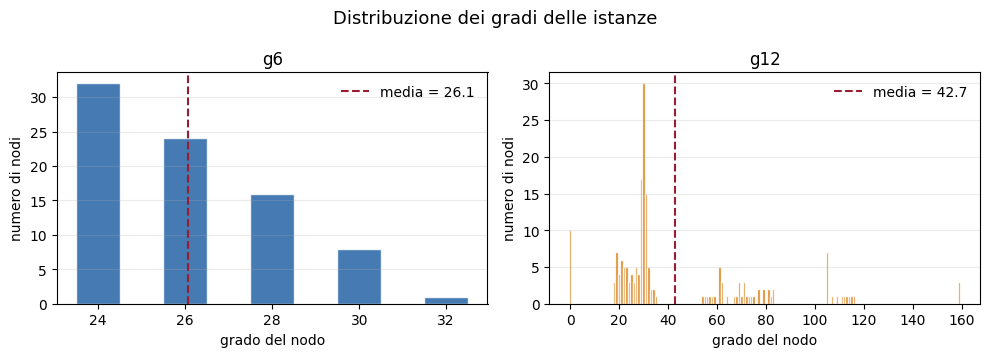

In [ ]:
# Distribuzione dei gradi delle due istanze
report_colors = {"g6": "#2563A6", "g12": "#D97706"}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, graph_name in zip(axes, ["g6", "g12"]):
    data = graphs[graph_name]
    degrees = torch.bincount(data.unique_edges.reshape(-1), minlength=data.num_nodes).cpu().numpy()
    bins = np.arange(degrees.min(), degrees.max() + 2) - 0.5

    ax.hist(degrees, bins=bins, color=report_colors[graph_name], alpha=0.85, edgecolor="white")
    ax.axvline(
        degrees.mean(),
        color="#9B1C31",
        linestyle="--",
        linewidth=1.5,
        label=f"media = {degrees.mean():.1f}",
    )
    ax.set_title(graph_name)
    ax.set_xlabel("grado del nodo")
    ax.set_ylabel("numero di nodi")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)

fig.suptitle("Distribuzione dei gradi delle istanze", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "degree_distributions.png", dpi=200, bbox_inches="tight")
plt.show()



> Questa figura mostra la **distribuzione dei gradi** per i grafi `g6` e `g12`.

*   Il grafico per `g6` indica che i nodi tendono ad avere gradi relativamente concentrati attorno alla media, suggerendo un grafo piuttosto denso e uniforme.
*   Per `g12`, la distribuzione mostra una maggiore variabilità, con alcuni nodi che hanno un grado molto elevato (hub) e altri con gradi inferiori. Questo può influenzare la complessità della colorazione e la propagazione delle informazioni nella GNN.

## **3. Baseline greedy**
 Viene applicata la funzione `networkx.greedy_color` con tre strategie. La baseline non sostituisce la GNN e non garantisce l'ottimalità, ma fornisce un upper bound pratico con cui confrontare la pipeline proposta.

In [ ]:
def to_networkx_graph(data: GraphData) -> nx.Graph:
    graph = nx.Graph()
    graph.add_nodes_from(range(data.num_nodes))
    graph.add_edges_from((int(u), int(v)) for u, v in data.unique_edges.t().tolist())
    return graph

def count_conflicts(colors: torch.Tensor, unique_edges: torch.Tensor) -> int:
    src, dst = unique_edges
    return int((colors[src] == colors[dst]).sum().item())

GREEDY_STRATEGIES = ["largest_first", "smallest_last", "saturation_largest_first"]

baseline_rows = []
baseline_colorings = {}
for graph_name, data in graphs.items():
    graph_nx = to_networkx_graph(data)
    num_edges = int(data.unique_edges.size(1))
    for strategy in GREEDY_STRATEGIES:
        color_dict = nx.greedy_color(graph_nx, strategy=strategy)
        colors = torch.tensor([color_dict[i] for i in range(data.num_nodes)], dtype=torch.long)
        conflicts = count_conflicts(colors, data.unique_edges)
        baseline_rows.append({
            "graph": graph_name,
            "strategy": strategy,
            "num_edges": num_edges,
            "num_colors": int(colors.unique().numel()),
            "conflicts": conflicts,
            "conflict_rate": conflicts / num_edges,
        })
        baseline_colorings[(graph_name, strategy)] = colors

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(TAB_DIR / "baseline_greedy.csv", index=False)
baseline_df

,graph,strategy,num_edges,num_colors,conflicts,conflict_rate
0,g6,largest_first,1056,15,0,0.0
1,g6,smallest_last,1056,16,0,0.0
2,g6,saturation_largest_first,1056,13,0,0.0
3,g12,largest_first,3973,31,0,0.0
4,g12,smallest_last,3973,32,0,0.0
5,g12,saturation_largest_first,3973,31,0,0.0


## **4. Strategia utilizzata e architettura della rete**
La rete viene allenata **da zero per ogni grafo e per ogni valore di `c`**. Non si cerca quindi un modello generalizzabile a nuovi grafi, ma i parametri che minimizzano l'energia dello specifico grafo in esame.

**Architettura**

La GNN comprende:
* un embedding trainabile per ciascun nodo;
* due layer di message passing che aggregano la media degli embedding dei vicini;
* trasformazioni lineari, ReLU e connessioni residuali;
* un layer lineare finale con `c` output per nodo. Applicando la softmax ai logits si ottiene, per ogni nodo `i`, una distribuzione `p_i` sui colori.

**Loss differenziabile**

La loss di Potts normalizzata sugli archi è:
$$L_{\mathrm{Potts}}=\frac{1}{|E|}\sum_{(i,j)\in E}\sum_{k=1}^{c}p_{ik}p_{jk}.$$La sovrapposizione tra le distribuzioni di due nodi adiacenti aumenta la loss. Viene inoltre aggiunto un termine entropico:$$L_{\mathrm{tot}}=L_{\mathrm{Potts}}+\lambda H,$$ $$\qquad H=-\frac{1}{|V|}\sum_i\sum_k p_{ik}\log p_{ik},$$
che, essendo minimizzato, favorisce assegnazioni più concentrate e vicine a vettori one-hot.

In [ ]:
class MeanMessagePassingLayer(nn.Module):
    """Semplice layer message passing: combina nodo e media dei vicini."""
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.self_linear = nn.Linear(hidden_dim, hidden_dim)
        self.neigh_linear = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])

        deg = torch.bincount(dst, minlength=x.size(0)).clamp(min=1).to(x.device).float()
        agg = agg / deg.unsqueeze(1)

        return self.self_linear(x) + self.neigh_linear(agg)

class GraphColoringGNN(nn.Module):
    def __init__(
        self,
        num_nodes: int,
        num_colors: int,
        hidden_dim: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        residual: bool = True,
    ):
        super().__init__()
        self.residual = residual
        self.embedding = nn.Embedding(num_nodes, hidden_dim)
        self.layers = nn.ModuleList([MeanMessagePassingLayer(hidden_dim) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dim, num_colors)

    def forward(self, data: GraphData) -> torch.Tensor:
        node_ids = torch.arange(data.num_nodes, device=data.edge_index.device)
        x = self.embedding(node_ids)

        for layer in self.layers:
            x_next = F.relu(layer(x, data.edge_index))
            if self.residual:
                x_next = x_next + x
            x = self.dropout(x_next)

        return self.out(x)

def potts_loss(
    logits: torch.Tensor,
    unique_edges: torch.Tensor,
    entropy_weight: float = 0.0,
    eps: float = 1e-12,
) -> torch.Tensor:
    probs = F.softmax(logits, dim=-1)
    src, dst = unique_edges
    potts = (probs[src] * probs[dst]).sum(dim=1).mean()

    if entropy_weight == 0:
        return potts

    entropy = -(probs * torch.log(probs + eps)).sum(dim=1).mean()
    return potts + entropy_weight * entropy

def discrete_coloring(logits: torch.Tensor) -> torch.Tensor:
    return torch.argmax(logits, dim=-1)

## **5. Dettagli del training, discretizzazione e post-processing**
L'ottimizzazione usa Adam e differenziazione automatica PyTorch. Per ogni configurazione vengono fissati seed, learning rate, numero massimo di epoche, dimensione nascosta e peso del termine entropico.Durante il training vengono monitorati separatamente:

* la loss continua usata dall'ottimizzatore;
* i conflitti della colorazione discreta ottenuta con `argmax`.

La migliore colorazione raw osservata durante il training viene poi usata per inizializzare una ricerca locale **min-conflicts**. Il notebook riporta sempre separatamente `raw_conflicts` e `repaired_conflicts`, perché il repair può essere determinante. Una colorazione è considerata valida soltanto quando una verifica indipendente conta zero conflitti.

In [ ]:
@dataclass
class TrainingConfig:
    num_colors: int
    seed: int = 0
    hidden_dim: int = 64
    num_layers: int = 2
    dropout: float = 0.0
    residual: bool = True
    lr: float = 1e-2
    weight_decay: float = 1e-5
    epochs: int = 700
    entropy_weight: float = 0.02
    log_every: int = 25
    repair_steps: int = 3000

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def repair_coloring(
    colors: torch.Tensor,
    unique_edges: torch.Tensor,
    num_colors: int,
    max_steps: int = 3000,
    seed: int = 0,
) -> dict:
    """Ricerca locale min-conflicts inizializzata dalla colorazione della GNN."""
    rng = random.Random(seed)
    colors = colors.detach().cpu().clone().long()
    edge_pairs = unique_edges.detach().cpu().t().tolist()

    neighbors = [[] for _ in range(colors.numel())]
    for u, v in edge_pairs:
        neighbors[u].append(v)
        neighbors[v].append(u)

    def current_conflicts() -> int:
        return sum(1 for u, v in edge_pairs if int(colors[u]) == int(colors[v]))

    def conflicted_nodes() -> list:
        bad = set()
        for u, v in edge_pairs:
            if int(colors[u]) == int(colors[v]):
                bad.add(u)
                bad.add(v)
        return list(bad)

    def node_conflicts(node: int, color: int) -> int:
        return sum(1 for nb in neighbors[node] if int(colors[nb]) == color)

    best_colors = colors.clone()
    best_conflicts = current_conflicts()
    history = [{"step": 0, "conflicts": best_conflicts}]

    for step in range(1, max_steps + 1):
        bad = conflicted_nodes()
        if not bad:
            best_colors = colors.clone()
            best_conflicts = 0
            history.append({"step": step, "conflicts": 0})
            break

        node = rng.choice(bad)
        scores = [node_conflicts(node, color) for color in range(num_colors)]
        min_score = min(scores)
        candidates = [color for color, score in enumerate(scores) if score == min_score]
        colors[node] = rng.choice(candidates)

        conflicts = current_conflicts()
        if conflicts < best_conflicts:
            best_conflicts = conflicts
            best_colors = colors.clone()

        if step == 1 or step % 100 == 0 or conflicts == 0:
            history.append({"step": step, "conflicts": conflicts})

    return {"colors": best_colors, "conflicts": best_conflicts, "history": history}

def train_single_run(data: GraphData, config: TrainingConfig, device=device) -> dict:
    set_seed(config.seed)
    data = data.to(device)

    model = GraphColoringGNN(
        num_nodes=data.num_nodes,
        num_colors=config.num_colors,
        hidden_dim=config.hidden_dim,
        num_layers=config.num_layers,
        dropout=config.dropout,
        residual=config.residual,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    history = []
    best = {
        "conflicts": None,
        "epoch": None,
        "loss": None,
        "colors": None,
        "logits": None,
    }

    for epoch in range(1, config.epochs + 1):
        model.train()
        logits = model(data)
        loss = potts_loss(logits, data.unique_edges, entropy_weight=config.entropy_weight)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        should_log = epoch == 1 or epoch % config.log_every == 0 or epoch == config.epochs
        if should_log:
            model.eval()
            with torch.no_grad():
                logits_eval = model(data)
                colors = discrete_coloring(logits_eval)
                conflicts = count_conflicts(colors.detach().cpu(), data.unique_edges.detach().cpu())
                loss_eval = float(potts_loss(logits_eval, data.unique_edges, config.entropy_weight).item())

            history.append({"epoch": epoch, "loss": loss_eval, "conflicts": conflicts})

            if best["conflicts"] is None or conflicts < best["conflicts"]:
                best = {
                    "conflicts": conflicts,
                    "epoch": epoch,
                    "loss": loss_eval,
                    "colors": colors.detach().cpu(),
                    "logits": logits_eval.detach().cpu(),
                }

            if conflicts == 0:
                break

    if config.repair_steps > 0:
        repaired = repair_coloring(
            best["colors"],
            data.unique_edges.detach().cpu(),
            config.num_colors,
            max_steps=config.repair_steps,
            seed=config.seed,
        )
    else:
        repaired = {"colors": best["colors"], "conflicts": best["conflicts"], "history": []}

    return {
        "model": model,
        "history": history,
        "best": best,
        "repaired": repaired,
        "config": config,
    }

def summarize_runs(runs: list) -> pd.DataFrame:
    compact_rows = [{k: v for k, v in run.items() if k not in {"history", "colors"}} for run in runs]
    if not compact_rows:
        return pd.DataFrame()

    rows = []
    for (graph, c), group in pd.DataFrame(compact_rows).groupby(["graph", "num_colors"]):
        rows.append({
            "graph": graph,
            "num_colors": int(c),
            "num_edges": int(group["num_edges"].iloc[0]),
            "best_conflicts": int(group["repaired_conflicts"].min()),
            "best_raw_conflicts": int(group["raw_conflicts"].min()),
            "best_conflict_rate": float(group["repaired_conflict_rate"].min()),
            "best_raw_conflict_rate": float(group["raw_conflict_rate"].min()),
            "mean_conflicts": float(group["repaired_conflicts"].mean()),
            "std_conflicts": float(group["repaired_conflicts"].std(ddof=0)),
            "mean_conflict_rate": float(group["repaired_conflict_rate"].mean()),
            "std_conflict_rate": float(group["repaired_conflict_rate"].std(ddof=0)),
            "success_rate": float((group["repaired_conflicts"] == 0).mean()),
            "best_seed": int(group.sort_values(["repaired_conflicts", "raw_conflicts"]).iloc[0]["seed"]),
            "num_runs": int(len(group)),
        })
    return pd.DataFrame(rows).sort_values(["graph", "num_colors"]).reset_index(drop=True)

def scan_color_counts(
    data: GraphData,
    c_values,
    seeds,
    base_config: TrainingConfig,
    device=device,
    verbose: bool = True,
) -> tuple:
    runs = []
    num_edges = int(data.unique_edges.size(1))

    for c in c_values:
        for seed in seeds:
            config = replace(base_config, num_colors=int(c), seed=int(seed))
            result = train_single_run(data, config, device=device)

            row = {
                "graph": data.name,
                "num_colors": int(c),
                "seed": int(seed),
                "num_edges": num_edges,
                "raw_conflicts": int(result["best"]["conflicts"]),
                "repaired_conflicts": int(result["repaired"]["conflicts"]),
                "raw_conflict_rate": int(result["best"]["conflicts"]) / num_edges,
                "repaired_conflict_rate": int(result["repaired"]["conflicts"]) / num_edges,
                "best_epoch": int(result["best"]["epoch"]),
                "best_loss": float(result["best"]["loss"]),
                "success": int(result["repaired"]["conflicts"] == 0),
                "history": result["history"],
                "colors": result["repaired"]["colors"],
            }
            runs.append(row)

            if verbose:
                print(
                    f"{data.name:>3} | c={c:2d} | seed={seed:2d} | "
                    f"raw={row['raw_conflicts']:4d} | repaired={row['repaired_conflicts']:4d} | "
                    f"epoch={row['best_epoch']:4d}"
                )

    return runs, summarize_runs(runs)

### **5.1 Sanity check**
Prima della scansione completa viene eseguito un test su `g6` con `c=9`. Il test controlla che training, discretizzazione, conteggio dei conflitti e grafico dell'andamento rispetto alle epoche funzionino correttamente.

In [ ]:
sanity_config = TrainingConfig(
    num_colors=9,
    seed=0,
    epochs=200,
    repair_steps=500,
    log_every=10,
)

sanity = train_single_run(graphs["g6"], sanity_config, device=device)
pd.DataFrame(sanity["history"]).tail()

,epoch,loss,conflicts
16,160,0.036036,38
17,170,0.036041,38
18,180,0.036044,38
19,190,0.036045,38
20,200,0.036044,38


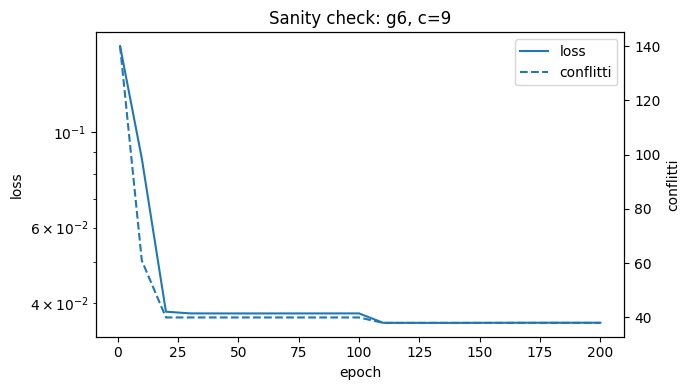

In [ ]:
def plot_training_history(history, title=None):
    hist = pd.DataFrame(history)
    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax2 = ax1.twinx()

    ax1.plot(hist["epoch"], hist["loss"], label="loss")
    ax2.plot(hist["epoch"], hist["conflicts"], label="conflitti", linestyle="--")

    ax1.set_xlabel("epoch")
    ax1.set_ylabel("loss")
    ax2.set_ylabel("conflitti")
    ax1.set_yscale("log")

    if title:
        ax1.set_title(title)

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")
    fig.tight_layout()
    return fig

fig = plot_training_history(sanity["history"], "Sanity check: g6, c=9")
fig.savefig(FIG_DIR / "sanity_g6_c9_training.png", dpi=160)
plt.show()

> Questa figura mostra l'andamento della loss e dei conflitti durante il training per il grafo g6 con c=9. Si osserva che la loss diminuisce costantemente, mentre i conflitti raggiungono un plateau. Questo indica che, sebbene il modello stia ancora ottimizzando la funzione di costo continua, la discretizzazione tramite argmax non porta a ulteriori riduzioni dei conflitti al di sotto di un certo valore dopo un certo numero di epoche.

## **6. Risultati: scansione nel numero di colori**
Per stimare la soglia di colorabilità vengono provati valori crescenti di `c`.

Per superare il problema dei minimi locali e garantire la stabilità dell'algoritmo, ogni combinazione di grafo e colore viene inizializzata e addestrata usando due seed casuali distinti, che vengono poi estesi a cinque nella successiva analisi di robustezza per un confronto più rigoroso.

Infine, per ciascun valore di $c$, le prestazioni del modello vengono valutate attraverso metriche specifiche: il minor numero di conflitti ottenuto, la media e la deviazione standard tra i diversi tentativi, la frequenza di successo nel trovare una colorazione valida e il tasso di errore normalizzato rispetto al numero totale di archi del grafo ($N_{conflicts} / |E|$)

In [ ]:
RUN_MODE = "final"   # valori possibili: "quick", "final"

if RUN_MODE == "quick":
    seeds = [0]
    scan_plan = {
        "g6": range(8, 12),
        "g12": range(20, 25),
    }
    base_config = TrainingConfig(
        num_colors=0,
        epochs=150,
        repair_steps=500,
        hidden_dim=64,
        num_layers=2,
        lr=1e-2,
        entropy_weight=0.02,
        log_every=25,
    )
elif RUN_MODE == "final":
    seeds = [0, 1]
    scan_plan = {
        "g6": range(8, 13),
        "g12": range(20, 37),
    }
    base_config = TrainingConfig(
        num_colors=0,
        epochs=700,
        repair_steps=3000,
        hidden_dim=64,
        num_layers=2,
        lr=1e-2,
        entropy_weight=0.02,
        log_every=25,
    )
else:
    raise ValueError("RUN_MODE deve essere 'quick' oppure 'final'.")

print("RUN_MODE:", RUN_MODE)
print("seeds:", seeds)
print("scan_plan:", {k: list(v) for k, v in scan_plan.items()})
print(base_config)

RUN_MODE: final
seeds: [0, 1]
scan_plan: {'g6': [8, 9, 10, 11, 12], 'g12': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]}
TrainingConfig(num_colors=0, seed=0, hidden_dim=64, num_layers=2, dropout=0.0, residual=True, lr=0.01, weight_decay=1e-05, epochs=700, entropy_weight=0.02, log_every=25, repair_steps=3000)


In [ ]:
all_runs = []
for graph_name, c_values in scan_plan.items():
    runs, _ = scan_color_counts(
        graphs[graph_name],
        c_values=c_values,
        seeds=seeds,
        base_config=base_config,
        device=device,
        verbose=True,
    )
    all_runs.extend(runs)

runs_df = pd.DataFrame([
    {k: v for k, v in run.items() if k not in {"history", "colors"}}
    for run in all_runs
])
summary_df = summarize_runs(all_runs)

runs_df.to_csv(TAB_DIR / "scan_runs.csv", index=False)
summary_df.to_csv(TAB_DIR / "scan_summary.csv", index=False)

summary_df

 g6 | c= 8 | seed= 0 | raw=  48 | repaired=  25 | epoch= 300
 g6 | c= 8 | seed= 1 | raw=  52 | repaired=  26 | epoch= 325
 g6 | c= 9 | seed= 0 | raw=  38 | repaired=  10 | epoch= 125
 g6 | c= 9 | seed= 1 | raw=  40 | repaired=  13 | epoch= 350
 g6 | c=10 | seed= 0 | raw=  36 | repaired=   6 | epoch=  25
 g6 | c=10 | seed= 1 | raw=  36 | repaired=   5 | epoch= 150
 g6 | c=11 | seed= 0 | raw=  17 | repaired=   0 | epoch=  50
 g6 | c=11 | seed= 1 | raw=  24 | repaired=   1 | epoch= 300
 g6 | c=12 | seed= 0 | raw=  18 | repaired=   0 | epoch=  25
 g6 | c=12 | seed= 1 | raw=  18 | repaired=   0 | epoch= 425
g12 | c=20 | seed= 0 | raw=  52 | repaired=  23 | epoch=  25
g12 | c=20 | seed= 1 | raw=  62 | repaired=  23 | epoch= 350
g12 | c=21 | seed= 0 | raw=  50 | repaired=  20 | epoch=  50
g12 | c=21 | seed= 1 | raw=  57 | repaired=  24 | epoch= 225
g12 | c=22 | seed= 0 | raw=  53 | repaired=  22 | epoch=  25
g12 | c=22 | seed= 1 | raw=  48 | repaired=  21 | epoch=  50
g12 | c=23 | seed= 0 | r

,graph,num_colors,num_edges,best_conflicts,best_raw_conflicts,best_conflict_rate,best_raw_conflict_rate,mean_conflicts,std_conflicts,mean_conflict_rate,std_conflict_rate,success_rate,best_seed,num_runs
0,g12,20,3973,23,52,0.005789,0.013088,23.0,0.0,0.005789,0.000000,0.0,0,2
1,g12,21,3973,20,50,0.005034,0.012585,22.0,2.0,0.005537,0.000503,0.0,0,2
2,g12,22,3973,21,48,0.005286,0.012082,21.5,0.5,0.005412,0.000126,0.0,1,2
3,g12,23,3973,19,43,0.004782,0.010823,19.5,0.5,0.004908,0.000126,0.0,0,2
4,g12,24,3973,17,39,0.004279,0.009816,17.0,0.0,0.004279,0.000000,0.0,0,2
5,g12,25,3973,15,35,0.003775,0.008809,16.0,1.0,0.004027,0.000252,0.0,1,2
6,g12,26,3973,14,45,0.003524,0.011326,15.5,1.5,0.003901,0.000378,0.0,1,2
7,g12,27,3973,13,38,0.003272,0.009565,14.0,1.0,0.003524,0.000252,0.0,1,2
8,g12,28,3973,12,42,0.003020,0.010571,13.0,1.0,0.003272,0.000252,0.0,1,2
9,g12,29,3973,8,32,0.002014,0.008054,10.5,2.5,0.002643,0.000629,0.0,1,2


### **6.1 Upper bound osservati nella scansione iniziale**
Con due seed, la pipeline GNN + repair trova la prima colorazione valida a:- `g6`: `c=11`;- `g12`: `c=36`.La baseline greedy trova invece upper bound pari a 13 per `g6` e 31 per `g12`. Di conseguenza, considerando questa prima scansione, il miglior upper bound complessivo è 11 per `g6` e 31 per `g12`.Questi valori sono risultati sperimentali e non dimostrano che colorazioni con meno colori siano impossibili.

In [ ]:
bounds_rows = []

for graph_name, group in summary_df.groupby("graph"):
    successful = group[group["best_conflicts"] == 0].sort_values("num_colors")
    gnn_first_success = None if successful.empty else int(successful.iloc[0]["num_colors"])

    graph_baseline = baseline_df[baseline_df["graph"] == graph_name]
    best_greedy = int(graph_baseline["num_colors"].min())

    if gnn_first_success is None:
        best_observed = best_greedy
    else:
        best_observed = min(gnn_first_success, best_greedy)

    bounds_rows.append({
        "graph": graph_name,
        "gnn_repair_first_successful_c": gnn_first_success,
        "best_greedy_c": best_greedy,
        "best_observed_upper_bound": best_observed,
    })

bounds_df = pd.DataFrame(bounds_rows).sort_values("graph").reset_index(drop=True)
bounds_df.to_csv(TAB_DIR / "coloring_bounds.csv", index=False)
bounds_df

,graph,gnn_repair_first_successful_c,best_greedy_c,best_observed_upper_bound
0,g12,36,31,31
1,g6,11,13,11


### **6.2 Verifica delle colorazioni finali**
Le migliori colorazioni a zero conflitti vengono salvate in formato CSV e controllate nuovamente sugli archi originali. La verifica separata evita di dichiarare valida una soluzione sulla sola base delle statistiche prodotte durante il training.

In [ ]:
verified_rows = []

for graph_name, data in graphs.items():
    candidates = [
        run for run in all_runs
        if run["graph"] == graph_name and int(run["repaired_conflicts"]) == 0
    ]

    if not candidates:
        print(f"Nessuna colorazione GNN+repair zero-conflitti trovata per {graph_name}.")
        continue

    best = min(candidates, key=lambda r: (r["num_colors"], r["seed"], r["raw_conflicts"]))
    colors = best["colors"].detach().cpu().long()
    verified_conflicts = count_conflicts(colors, data.unique_edges)

    coloring_file = f"{graph_name}_c{best['num_colors']}_seed{best['seed']}_coloring.csv"
    pd.DataFrame({
        "node_zero_based": np.arange(data.num_nodes),
        "node_dimacs": np.arange(1, data.num_nodes + 1),
        "color": colors.numpy(),
    }).to_csv(TAB_DIR / coloring_file, index=False)

    verified_rows.append({
        "graph": graph_name,
        "target_c": int(best["num_colors"]),
        "seed": int(best["seed"]),
        "raw_conflicts": int(best["raw_conflicts"]),
        "repaired_conflicts": int(best["repaired_conflicts"]),
        "verified_conflicts": int(verified_conflicts),
        "colors_used": int(colors.unique().numel()),
        "coloring_file": coloring_file,
        "valid_coloring": verified_conflicts == 0,
    })

verified_df = pd.DataFrame(verified_rows)
verified_df.to_csv(TAB_DIR / "final_verified_colorings.csv", index=False)
verified_df

,graph,target_c,seed,raw_conflicts,repaired_conflicts,verified_conflicts,colors_used,coloring_file,valid_coloring
0,g6,11,0,17,0,0,11,g6_c11_seed0_coloring.csv,True
1,g12,36,0,28,0,0,36,g12_c36_seed0_coloring.csv,True


In [ ]:
if not verified_df.empty:
    assert verified_df["valid_coloring"].all(), "Almeno una colorazione finale contiene conflitti."
    print("Tutte le colorazioni finali verificate hanno 0 conflitti.")
else:
    print("Nessuna colorazione zero-conflitti verificata nella scansione eseguita.")

Tutte le colorazioni finali verificate hanno 0 conflitti.


### **6.3 Grafici dei risultati**
I grafici mostrano il miglior numero di conflitti e la media sui seed al variare di `c`. Per le colorazioni valide vengono inoltre visualizzati i grafi colorati; eventuali archi in conflitto sarebbero evidenziati.

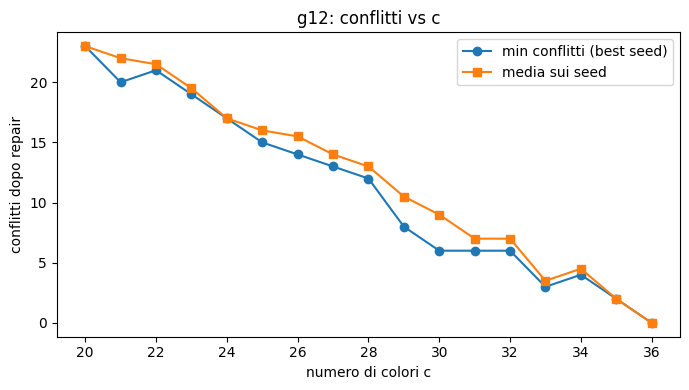

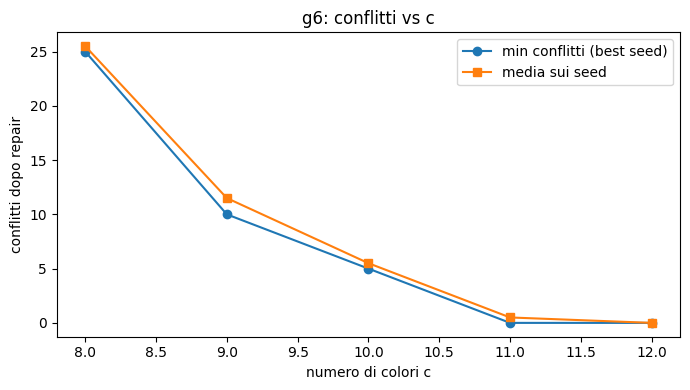

In [ ]:
def plot_conflicts_by_c(summary_df: pd.DataFrame, graph_name: str):
    subset = summary_df[summary_df["graph"] == graph_name].sort_values("num_colors")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(subset["num_colors"], subset["best_conflicts"], marker="o", label="min conflitti (best seed)")
    ax.plot(subset["num_colors"], subset["mean_conflicts"], marker="s", label="media sui seed")
    ax.set_xlabel("numero di colori c")
    ax.set_ylabel("conflitti dopo repair")
    ax.set_title(f"{graph_name}: conflitti vs c")
    ax.legend()
    fig.tight_layout()
    return fig

for graph_name in summary_df["graph"].unique():
    fig = plot_conflicts_by_c(summary_df, graph_name)
    fig.savefig(FIG_DIR / f"{graph_name}_conflicts_by_c.png", dpi=160)
    plt.show()


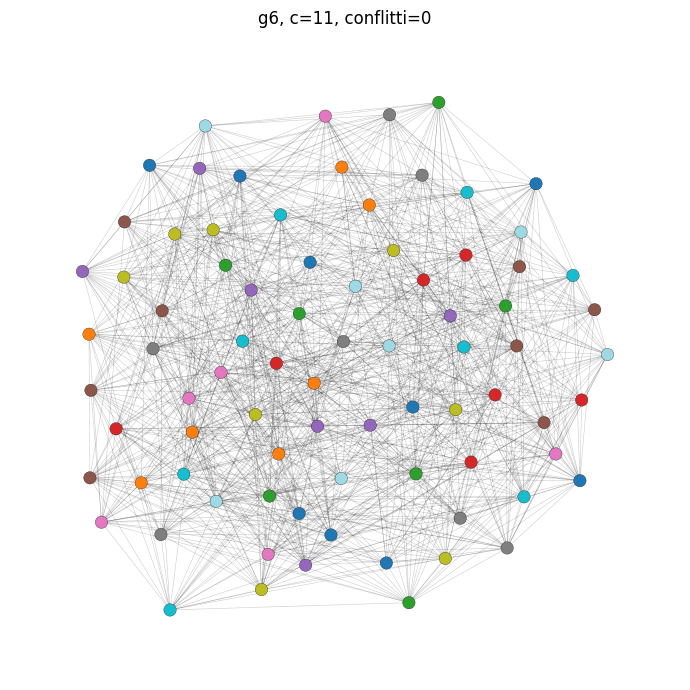

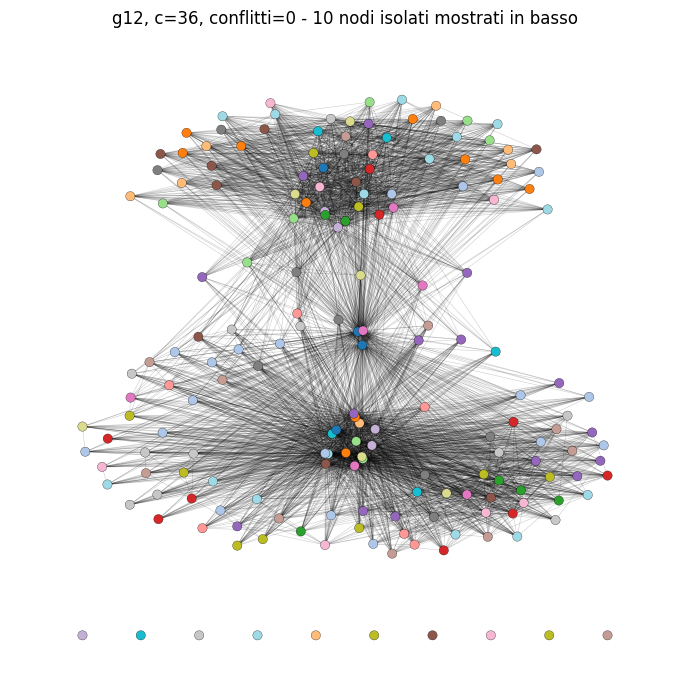

In [ ]:
def graph_layout_with_isolates(graph: nx.Graph, seed: int = 0, layout_iterations: int = 80, layout_k: float = None):
    """Layout stabile: componente principale al centro, nodi isolati in una riga separata."""
    isolated_nodes = list(nx.isolates(graph))
    connected_nodes = [node for node in graph.nodes() if node not in isolated_nodes]

    if connected_nodes:
        connected_graph = graph.subgraph(connected_nodes)
        pos = nx.spring_layout(connected_graph, seed=seed, iterations=layout_iterations, k=layout_k)
    else:
        pos = {}

    if isolated_nodes:
        if pos:
            xs = np.array([point[0] for point in pos.values()])
            ys = np.array([point[1] for point in pos.values()])
            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()
            y_iso = y_min - 0.18 * max(y_max - y_min, 1.0)
        else:
            x_min, x_max, y_iso = -1.0, 1.0, 0.0

        if len(isolated_nodes) == 1:
            iso_xs = [0.0]
        else:
            iso_xs = np.linspace(x_min, x_max, len(isolated_nodes))
        for node, x in zip(sorted(isolated_nodes), iso_xs):
            pos[node] = np.array([float(x), float(y_iso)])

    return pos, isolated_nodes


def plot_colored_graph(data: GraphData, colors: torch.Tensor, title: str = "", seed: int = 0, layout_iterations: int = 80, layout_k: float = None):
    graph = to_networkx_graph(data)
    colors = colors.detach().cpu().long()
    conflict_edges = [
        (u, v) for u, v in graph.edges()
        if int(colors[u]) == int(colors[v])
    ]

    pos, isolated_nodes = graph_layout_with_isolates(graph, seed=seed, layout_iterations=layout_iterations, layout_k=layout_k)

    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_edges(graph, pos, ax=ax, width=0.4, alpha=0.20)
    if conflict_edges:
        nx.draw_networkx_edges(graph, pos, edgelist=conflict_edges, ax=ax, width=1.5)

    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=[int(colors[i]) for i in graph.nodes()],
        cmap=plt.cm.tab20,
        node_size=80 if data.num_nodes <= 100 else 45,
        linewidths=0.2,
        edgecolors="black",
        ax=ax,
    )

    if isolated_nodes:
        subtitle = f"{title} - {len(isolated_nodes)} nodi isolati mostrati in basso"
    else:
        subtitle = title
    ax.set_title(subtitle)
    ax.set_axis_off()
    ax.margins(0.08)
    fig.tight_layout()
    return fig

for _, row in verified_df.iterrows():
    graph_name = row["graph"]
    data = graphs[graph_name]
    coloring = pd.read_csv(TAB_DIR / row["coloring_file"]).sort_values("node_zero_based")
    colors = torch.tensor(coloring["color"].values, dtype=torch.long)
    fig = plot_colored_graph(data, colors, title=f"{graph_name}, c={row['target_c']}, conflitti=0", seed=0)
    fig.savefig(FIG_DIR / f"{graph_name}_final_colored_graph.png", dpi=180)
    plt.show()


In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display

# Filter for g12 from verified_df
g12_row = verified_df[verified_df['graph'] == 'g12'].iloc[0]


def plot_g12_interactive(layout_seed: int, layout_iterations: int, layout_k_value: float):
    data = graphs[g12_row["graph"]]
    coloring = pd.read_csv(TAB_DIR / g12_row["coloring_file"]).sort_values("node_zero_based")
    colors = torch.tensor(coloring["color"].values, dtype=torch.long)
    final_layout_k = layout_k_value if layout_k_value > 0.0 else None

    fig = plot_colored_graph(
        data,
        colors,
        title=f"{g12_row['graph']}, c={g12_row['target_c']}, conflitti=0",
        seed=layout_seed,
        layout_iterations=layout_iterations,
        layout_k=final_layout_k,
    )
    plt.show()

layout_seed_widget = widgets.IntSlider(min=0, max=100000, step=1, value=0, description='Layout Seed')
layout_iterations_widget = widgets.IntSlider(min=1, max=500, step=1, value=80, description='Layout Iterations')
layout_k_widget = widgets.FloatSlider(min=0.0, max=5.0, step=0.01, value=0.0, description='Layout K')

widgets.interact(
    plot_g12_interactive,
    layout_seed=layout_seed_widget,
    layout_iterations=layout_iterations_widget,
    layout_k_value=layout_k_widget,
);


interactive(children=(IntSlider(value=0, description='Layout Seed', max=100000), IntSlider(value=80, descripti…

In [ ]:
from IPython.display import Image, display



> È comune che, nelle visualizzazioni di grafi densi o con un elevato numero di nodi, alcuni di essi possano apparire 'sovrapposti' o troppo ravvicinati.
Per migliorare la leggibilità e ridurre l'impressione di sovrapposizione, si possono sfruttare i controlli interattivi della cella precedente. In particolare, la modifica dei parametri `Layout Seed`, `Layout Iterations` e `Layout K` può generare layout diversi e talvolta più chiari per lo stesso grafo.



## **7. Test di robustezza**
Per valutare meglio la sensibilità all'inizializzazione, la scansione viene ripetuta con cinque seed mantenendo invariati architettura e iperparametri. L'obiettivo è confrontare `mean_conflicts`, deviazione standard e `success_rate` con la scansione iniziale a due seed.

In [ ]:
# Nuova configurazione per i test di robustezza
ROBUSTNESS_RUN_MODE = "robustness_test"

if ROBUSTNESS_RUN_MODE == "robustness_test":
    # Aumentiamo il numero di seed per una valutazione più robusta
    robustness_seeds = list(range(5)) # 5 seed diversi
    # Manteniamo lo stesso scan_plan della run 'final' per coerenza
    robustness_scan_plan = {
        "g6": range(8, 13),
        "g12": range(20, 37),
    }
    # Manteniamo la stessa configurazione di training della run 'final'
    robustness_base_config = TrainingConfig(
        num_colors=0,
        epochs=700,
        repair_steps=3000,
        hidden_dim=64,
        num_layers=2,
        lr=1e-2,
        entropy_weight=0.02,
        log_every=25,
    )
else:
    raise ValueError("ROBUSTNESS_RUN_MODE deve essere 'robustness_test'.")

print("ROBUSTNESS_RUN_MODE:", ROBUSTNESS_RUN_MODE)
print("robustness_seeds:", robustness_seeds)
print("robustness_scan_plan:", {k: list(v) for k, v in robustness_scan_plan.items()})
print(robustness_base_config)

ROBUSTNESS_RUN_MODE: robustness_test
robustness_seeds: [0, 1, 2, 3, 4]
robustness_scan_plan: {'g6': [8, 9, 10, 11, 12], 'g12': [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]}
TrainingConfig(num_colors=0, seed=0, hidden_dim=64, num_layers=2, dropout=0.0, residual=True, lr=0.01, weight_decay=1e-05, epochs=700, entropy_weight=0.02, log_every=25, repair_steps=3000)


### **7.1 Esecuzione della scansione con cinque seed**
La scansione di robustezza usa gli stessi valori di `c` dell'esperimento finale. I risultati dei cinque seed comprendono anche i primi due seed della scansione precedente, consentendo un confronto diretto.

In [ ]:
robustness_all_runs = []
for graph_name, c_values in robustness_scan_plan.items():
    runs, _ = scan_color_counts(
        graphs[graph_name],
        c_values=c_values,
        seeds=robustness_seeds,
        base_config=robustness_base_config,
        device=device,
        verbose=True,
    )
    robustness_all_runs.extend(runs)

robustness_runs_df = pd.DataFrame([
    {k: v for k, v in run.items() if k not in {"history", "colors"}}
    for run in robustness_all_runs
])
robustness_summary_df = summarize_runs(robustness_all_runs)

# Salviamo i risultati di questa nuova scansione
robustness_runs_df.to_csv(TAB_DIR / "robustness_scan_runs.csv", index=False)
robustness_summary_df.to_csv(TAB_DIR / "robustness_scan_summary.csv", index=False)

print("\nRisultati della scansione di robustezza (primi 5):")
display(robustness_summary_df.head())

 g6 | c= 8 | seed= 0 | raw=  48 | repaired=  25 | epoch= 300
 g6 | c= 8 | seed= 1 | raw=  52 | repaired=  26 | epoch= 325
 g6 | c= 8 | seed= 2 | raw=  53 | repaired=  26 | epoch=  50
 g6 | c= 8 | seed= 3 | raw=  56 | repaired=  28 | epoch=  25
 g6 | c= 8 | seed= 4 | raw=  45 | repaired=  27 | epoch= 200
 g6 | c= 9 | seed= 0 | raw=  38 | repaired=  10 | epoch= 125
 g6 | c= 9 | seed= 1 | raw=  40 | repaired=  13 | epoch= 350
 g6 | c= 9 | seed= 2 | raw=  44 | repaired=  12 | epoch=  50
 g6 | c= 9 | seed= 3 | raw=  44 | repaired=  13 | epoch=  50
 g6 | c= 9 | seed= 4 | raw=  44 | repaired=  11 | epoch=  25
 g6 | c=10 | seed= 0 | raw=  36 | repaired=   6 | epoch=  25
 g6 | c=10 | seed= 1 | raw=  36 | repaired=   5 | epoch= 150
 g6 | c=10 | seed= 2 | raw=  32 | repaired=   2 | epoch= 300
 g6 | c=10 | seed= 3 | raw=  34 | repaired=   2 | epoch=  25
 g6 | c=10 | seed= 4 | raw=  35 | repaired=   1 | epoch=  75
 g6 | c=11 | seed= 0 | raw=  17 | repaired=   0 | epoch=  50
 g6 | c=11 | seed= 1 | r

,graph,num_colors,num_edges,best_conflicts,best_raw_conflicts,best_conflict_rate,best_raw_conflict_rate,mean_conflicts,std_conflicts,mean_conflict_rate,std_conflict_rate,success_rate,best_seed,num_runs
0,g12,20,3973,23,44,0.005789,0.011075,23.4,0.489898,0.005890,0.000123,0.0,4,5
1,g12,21,3973,20,41,0.005034,0.010320,22.2,1.469694,0.005588,0.000370,0.0,0,5
2,g12,22,3973,21,42,0.005286,0.010571,21.2,0.400000,0.005336,0.000101,0.0,2,5
3,g12,23,3973,17,37,0.004279,0.009313,18.8,1.166190,0.004732,0.000294,0.0,4,5
4,g12,24,3973,15,38,0.003775,0.009565,16.6,1.496663,0.004178,0.000377,0.0,3,5


### **7.2 Analisi della robustezza**
I risultati mostrano due regimi. Vicino alla soglia, il metodo è sensibile all'inizializzazione: `g6, c=11` ha success rate `0.40`, mentre `g12, c=35` ha success rate `0.40` e viene risolto soltanto grazie ai seed aggiuntivi. Con un colore in più, `g6, c=12` e `g12, c=36` raggiungono success rate `1.00` e media dei conflitti pari a zero.La scansione a cinque seed migliora quindi l'upper bound GNN + repair di `g12` da 36 a 35, ma conferma anche che il successo vicino alla soglia non è stabile rispetto all'inizializzazione.

Tabella riassuntiva precedente (2 seed):


,graph,num_colors,num_edges,best_conflicts,best_raw_conflicts,best_conflict_rate,best_raw_conflict_rate,mean_conflicts,std_conflicts,mean_conflict_rate,std_conflict_rate,success_rate,best_seed,num_runs
0,g12,20,3973,23,52,0.005789,0.013088,23.0,0.0,0.005789,0.000000,0.0,0,2
1,g12,21,3973,20,50,0.005034,0.012585,22.0,2.0,0.005537,0.000503,0.0,0,2
2,g12,22,3973,21,48,0.005286,0.012082,21.5,0.5,0.005412,0.000126,0.0,1,2
3,g12,23,3973,19,43,0.004782,0.010823,19.5,0.5,0.004908,0.000126,0.0,0,2
4,g12,24,3973,17,39,0.004279,0.009816,17.0,0.0,0.004279,0.000000,0.0,0,2



Tabella riassuntiva della nuova scansione (5 seed):


,graph,num_colors,num_edges,best_conflicts,best_raw_conflicts,best_conflict_rate,best_raw_conflict_rate,mean_conflicts,std_conflicts,mean_conflict_rate,std_conflict_rate,success_rate,best_seed,num_runs
0,g12,20,3973,23,44,0.005789,0.011075,23.4,0.489898,0.005890,0.000123,0.0,4,5
1,g12,21,3973,20,41,0.005034,0.010320,22.2,1.469694,0.005588,0.000370,0.0,0,5
2,g12,22,3973,21,42,0.005286,0.010571,21.2,0.400000,0.005336,0.000101,0.0,2,5
3,g12,23,3973,17,37,0.004279,0.009313,18.8,1.166190,0.004732,0.000294,0.0,4,5
4,g12,24,3973,15,38,0.003775,0.009565,16.6,1.496663,0.004178,0.000377,0.0,3,5


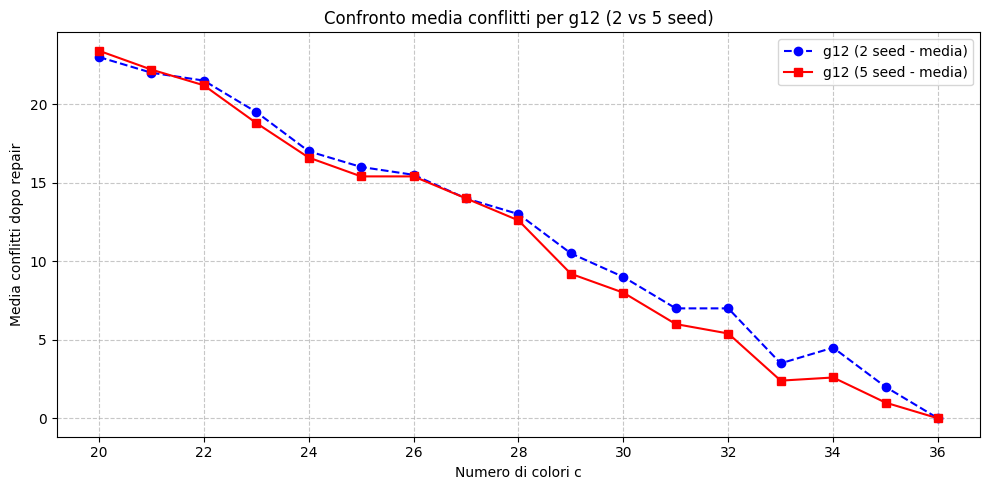

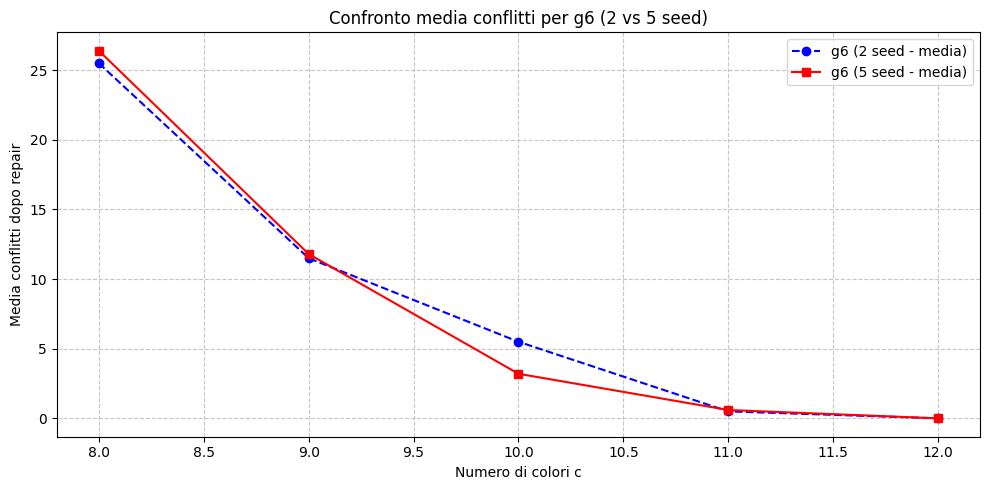

In [ ]:
print("Tabella riassuntiva precedente (2 seed):")
display(summary_df.head())

print("\nTabella riassuntiva della nuova scansione (5 seed):")
display(robustness_summary_df.head())

# Confronto grafico
def plot_conflicts_comparison(original_df: pd.DataFrame, new_df: pd.DataFrame, graph_name: str):
    fig, ax = plt.subplots(figsize=(10, 5))

    subset_orig = original_df[original_df["graph"] == graph_name].sort_values("num_colors")
    subset_new = new_df[new_df["graph"] == graph_name].sort_values("num_colors")

    ax.plot(subset_orig["num_colors"], subset_orig["mean_conflicts"], marker="o", linestyle='--', label=f"{graph_name} (2 seed - media)", color='blue')
    ax.plot(subset_new["num_colors"], subset_new["mean_conflicts"], marker="s", linestyle='-', label=f"{graph_name} (5 seed - media)", color='red')

    ax.set_xlabel("Numero di colori c")
    ax.set_ylabel("Media conflitti dopo repair")
    ax.set_title(f"Confronto media conflitti per {graph_name} (2 vs 5 seed)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()

for graph_name in robustness_summary_df["graph"].unique():
    plot_conflicts_comparison(summary_df, robustness_summary_df, graph_name)




> I grafici illustrano l'andamento dei conflitti residui in funzione del numero di colori ($c$) per i grafi g6 e g12, dopo l'addestramento della GNN e la successiva ricerca locale. Ogni grafico riporta una linea blu, che indica il numero minimo di conflitti registrato tra tutte le esecuzioni, e una linea arancione, che rappresenta la media dei conflitti sui vari seed per valutare la stabilità tipica del metodo. Osservando la naturale discesa dei conflitti all'aumentare di $c$, lo scopo è individuare il valore più basso per cui la curva blu tocca lo zero, indicando che il modello ha trovato una colorazione valida.


### **7.3 Verifica delle migliori soluzioni della scansione robusta**
Le migliori soluzioni trovate con cinque seed vengono salvate e verificate nuovamente. La scansione robusta conferma una colorazione valida per `g6` con 11 colori e trova una colorazione valida per `g12` con 35 colori.

In [ ]:
robustness_verified_rows = []

for graph_name, data in graphs.items():
    candidates = [
        run for run in robustness_all_runs
        if run["graph"] == graph_name and int(run["repaired_conflicts"]) == 0
    ]

    if not candidates:
        print(f"Nessuna colorazione GNN+repair zero-conflitti trovata per {graph_name} con 5 seed.")
        continue

    # Prendiamo il migliore in base a num_colors, poi seed, poi raw_conflicts
    best = min(candidates, key=lambda r: (r["num_colors"], r["seed"], r["raw_conflicts"]))
    colors = best["colors"].detach().cpu().long()
    verified_conflicts = count_conflicts(colors, data.unique_edges)

    coloring_file = f"{graph_name}_c{best['num_colors']}_seed{best['seed']}_robustness_coloring.csv"
    pd.DataFrame({
        "node_zero_based": np.arange(data.num_nodes),
        "node_dimacs": np.arange(1, data.num_nodes + 1),
        "color": colors.numpy(),
    }).to_csv(TAB_DIR / coloring_file, index=False)

    robustness_verified_rows.append({
        "graph": graph_name,
        "target_c": int(best["num_colors"]),
        "seed": int(best["seed"]),
        "raw_conflicts": int(best["raw_conflicts"]),
        "repaired_conflicts": int(best["repaired_conflicts"]),
        "verified_conflicts": int(verified_conflicts),
        "colors_used": int(colors.unique().numel()),
        "coloring_file": coloring_file,
        "valid_coloring": verified_conflicts == 0,
    })

robustness_verified_df = pd.DataFrame(robustness_verified_rows)
robustness_verified_df.to_csv(TAB_DIR / "final_verified_colorings_robustness.csv", index=False)
print("\nColorazioni verificate con la scansione di robustezza:")
display(robustness_verified_df)

if not robustness_verified_df.empty:
    assert robustness_verified_df["valid_coloring"].all(), "Almeno una colorazione finale di robustezza contiene conflitti."
    print("Tutte le colorazioni finali verificate con la scansione di robustezza hanno 0 conflitti.")
else:
    print("Nessuna colorazione zero-conflitti verificata nella scansione di robustezza.")


Colorazioni verificate con la scansione di robustezza:


,graph,target_c,seed,raw_conflicts,repaired_conflicts,verified_conflicts,colors_used,coloring_file,valid_coloring
0,g6,11,0,17,0,0,11,g6_c11_seed0_robustness_coloring.csv,True
1,g12,35,2,28,0,0,35,g12_c35_seed2_robustness_coloring.csv,True


Tutte le colorazioni finali verificate con la scansione di robustezza hanno 0 conflitti.


### **7.4 Visualizzazione delle colorazioni valide**
I grafici seguenti mostrano le migliori colorazioni a zero conflitti ottenute nella scansione a cinque seed.

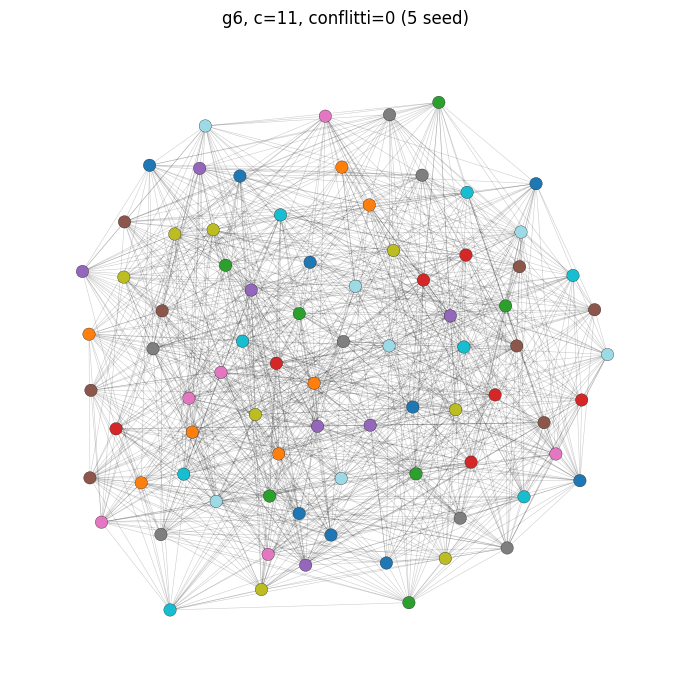

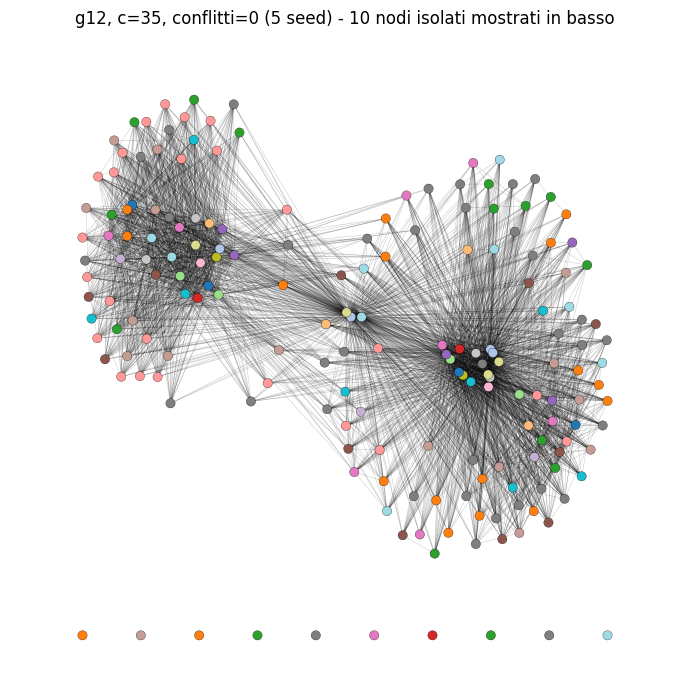

In [ ]:
for _, row in robustness_verified_df.iterrows():
    graph_name = row["graph"]
    data = graphs[graph_name]
    coloring = pd.read_csv(TAB_DIR / row["coloring_file"]).sort_values("node_zero_based")
    colors = torch.tensor(coloring["color"].values, dtype=torch.long)
    fig = plot_colored_graph(data, colors, title=f"{graph_name}, c={row['target_c']}, conflitti=0 (5 seed)", seed=row['seed'])
    fig.savefig(FIG_DIR / f"{graph_name}_final_colored_graph_robustness_seed{row['seed']}.png", dpi=180)
    plt.show()

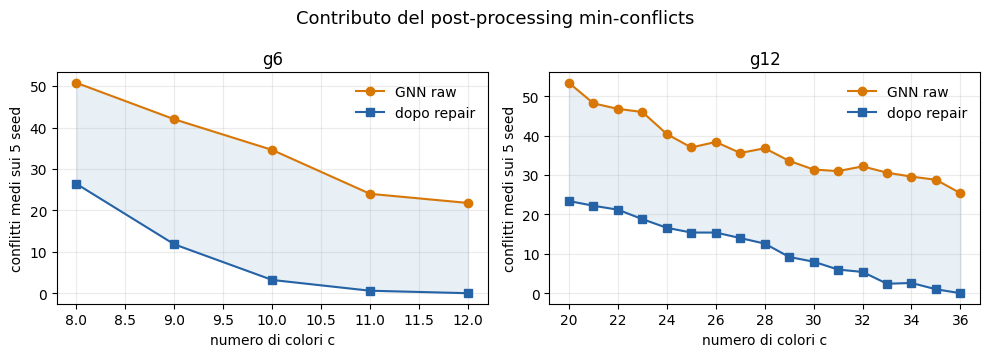

In [ ]:
# Contributo medio del post-processing min-conflicts
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, graph_name in zip(axes, ["g6", "g12"]):
    subset = robustness_runs_df[robustness_runs_df["graph"] == graph_name]
    repair_summary = subset.groupby("num_colors")[["raw_conflicts", "repaired_conflicts"]].mean()

    ax.plot(
        repair_summary.index,
        repair_summary["raw_conflicts"],
        marker="o",
        color="#D97706",
        label="GNN raw",
    )
    ax.plot(
        repair_summary.index,
        repair_summary["repaired_conflicts"],
        marker="s",
        color="#2563A6",
        label="dopo repair",
    )
    ax.fill_between(
        repair_summary.index,
        repair_summary["repaired_conflicts"],
        repair_summary["raw_conflicts"],
        color="#2563A6",
        alpha=0.10,
    )
    ax.set_title(graph_name)
    ax.set_xlabel("numero di colori c")
    ax.set_ylabel("conflitti medi sui 5 seed")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

fig.suptitle("Contributo del post-processing min-conflicts", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "raw_vs_repair_mean_conflicts.png", dpi=200, bbox_inches="tight")
plt.show()

Questa figura illustra il **contributo del post-processing min-conflicts** confrontando il numero medio di conflitti prima e dopo l'applicazione della procedura di repair, per i grafi `g6` e `g12`.

*   La **linea arancione (GNN raw)** mostra il numero medio di conflitti ottenuti direttamente dalla GNN (dopo `argmax`) sui cinque seed.
*   La **linea blu (dopo repair)** mostra il numero medio di conflitti dopo l'applicazione del post-processing `min-conflicts`.

L'area ombreggiata tra le due linee evidenzia la **riduzione dei conflitti** apportata dal `repair`. Si osserva chiaramente come il `min-conflicts` sia efficace nel ridurre drasticamente i conflitti residui della GNN. Questo grafico sottolinea l'importanza cruciale della fase di post-processing per la pipeline completa.

## **8. Discussione critica**

L'analisi del metodo GNN per la colorazione dei grafi rivela diverse caratteristiche importanti. Innanzitutto, è fondamentale notare che l'ottimizzazione è intrinsecamente **non convessa**, il che significa che il metodo non converge sempre a una soluzione unica e ottima. Configurazioni identiche (stesso grafo e stesso `c`) possono produrre risultati con numeri di conflitti diversi, un fenomeno particolarmente evidente quando ci si avvicina alla soglia di colorabilità.

La **dipendenza dall'inizializzazione casuale** (il seed) è significativa. Nei casi più critici, come per `g6` con `c=11` o `g12` con `c=35`, il successo nel trovare una colorazione valida varia notevolmente a seconda del seed. Ad esempio, `g12, c=35` viene risolto solo grazie all'uso di seed aggiuntivi nella scansione di robustezza, suggerendo che la ricerca del minimo globale è complessa. Al contrario, per valori di `c` leggermente superiori (`g6, c=12` e `g12, c=36`), il metodo mostra una maggiore stabilità, raggiungendo zero conflitti in tutti i seed testati.

Per quanto riguarda i **valori di `c` sufficienti**, la scansione più robusta individua colorazioni valide (dopo il post-processing di repair) con `c=11` per `g6` e `c=35` per `g12`. È cruciale ribadire che questi rappresentano **upper bound osservati** della pipeline e non dimostrazioni matematiche del numero cromatico esatto. Interessante è il confronto con la baseline greedy: per `g12`, questa produce un upper bound migliore (`c=31`) rispetto alla pipeline GNN + repair, evidenziando che una maggiore complessità del modello non garantisce necessariamente una superiorità.

Un aspetto chiave da considerare è la distinzione tra l'ottimizzazione della **loss continua** e la **validità della colorazione discreta**. La loss, agendo su distribuzioni continue, può continuare a diminuire anche quando il numero di conflitti discreti rimane costante. Per questo motivo, è essenziale monitorare separatamente la loss e i conflitti effettivi.

Il **ruolo del post-processing** (il repair locale) è decisivo per i successi osservati. Soluzioni iniziali con numerosi conflitti possono essere "riparate" a zero conflitti, come dimostrato dai passaggi da 17 a 0 conflitti per `g6, c=11` e da 28 a 0 per `g12, c=35`. Questo sottolinea che la pipeline completa dovrebbe essere intesa come **GNN + repair**, piuttosto che la sola GNN.

I **limiti del metodo** includono la sua sensibilità a seed e iperparametri, la già citata discrepanza tra obiettivo continuo e problema discreto, il costo computazionale elevato per la scansione di `c` e l'assenza di garanzie matematiche di ottimalità.

Per quanto riguarda i **possibili miglioramenti**, si potrebbero esplorare strategie come l'aumento dei restart, lo scheduling dinamico del learning rate e del termine entropico, l'adozione di architetture GNN più avanzate, il monitoraggio esplicito dell'entropia delle distribuzioni di colore per favorire assegnazioni più nette e l'implementazione di procedure di repair più sofisticate. Inoltre, sarebbe utile isolare il contributo specifico della GNN confrontando il repair locale con inizializzazioni puramente casuali o basate su greedy.

### **8.1 Complessità computazionale e tempi di esecuzione**

Un aspetto pratico rilevante del metodo proposto è l'**elevato costo computazionale**. A differenza di un'euristica greedy che produce una soluzione in frazioni di secondo, questa pipeline richiede diversi minuti (o ore, a seconda dell'hardware e del numero di seed) per completare una scansione.

Questo tempo è giustificato da tre fattori principali:
1. **Training dedicato**: La GNN non è pre-addestrata; i pesi vengono ottimizzati da zero per ogni singolo grafo e per ogni valore di `c`.
2. **Esplorazione stocastica**: Per superare il problema dei minimi locali e della non-convessità della loss di Potts, è necessario ripetere l'esperimento con più inizializzazioni casuali (seed).
3. **Post-processing**: La fase di `repair_coloring` esegue fino a 3000 iterazioni di ricerca locale per ogni run, un passaggio fondamentale per convertire l'output continuo della GNN in una colorazione discreta valida.

In sintesi, il metodo scambia l'efficienza temporale con la possibilità di esplorare lo spazio delle soluzioni in modo più flessibile rispetto a un algoritmo puramente deterministico.

## 9. Esportazione dei risultati
La cella seguente comprime la cartella `results` in `results.zip`, così da rendere disponibili tabelle, colorazioni verificate e figure prodotte durante l'esecuzione.

In [ ]:
!zip -r /content/results.zip {RESULTS_DIR.as_posix()}
print(f"File 'results.zip' creato in /content/results.zip")

  adding: content/results/ (stored 0%)
  adding: content/results/figures/ (stored 0%)
  adding: content/results/figures/g6_conflicts_by_c.png (deflated 10%)
  adding: content/results/figures/raw_vs_repair_mean_conflicts.png (deflated 9%)
  adding: content/results/figures/g12_conflicts_by_c.png (deflated 8%)
  adding: content/results/figures/degree_distributions.png (deflated 17%)
  adding: content/results/figures/g12_final_colored_graph_robustness_seed2.png (deflated 11%)
  adding: content/results/figures/g6_final_colored_graph_robustness_seed0.png (deflated 9%)
  adding: content/results/figures/g12_final_colored_graph.png (deflated 10%)
  adding: content/results/figures/g6_final_colored_graph.png (deflated 9%)
  adding: content/results/figures/sanity_g6_c9_training.png (deflated 12%)
  adding: content/results/tables/ (stored 0%)
  adding: content/results/tables/g6_c11_seed0_robustness_coloring.csv (deflated 52%)
  adding: content/results/tables/baseline_greedy.csv (deflated 54%)
  add